In [27]:
%load_ext autoreload
%autoreload 2
cmd = "W"
import sys
parent_dir = "C:/Users/yuhang.hou/projects/holidays/poc_backtester/data_pipeline/universal"

import json
import pandas as pd
import os
import pickle
sys.path.append(parent_dir)
holidays_path = "C:/Users/yuhang.hou/projects/holidays"
sys.path.append(holidays_path)
from backtester import *
from utils import *

last_trading_days = get_last_trading_days(cmd)
ltds = {k:pd.to_datetime(v) for k,v in last_trading_days.items()}

business_days = load_business_days_cmd(cmd)
business_days = sorted(business_days)

def process_results(results):
    res =[]
    for date, data in results.items():
        try:
            temp= { }
            temp['date'] = date
            temp['level'] = data['level']
            temp['tc'] = data['tc']
            res.append(temp)
        except Exception as e:
            print(f"Error processing date {data}: {e}")
    res = pd.DataFrame(res)
    res = res.set_index('date')
    res['tc_cumsum'] = res['tc'].cumsum()
    return res

def load_future_data(data_path = f'./data/{cmd}',values = 'close'):
    files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
    dfs = (pd.read_csv(os.path.join(data_path, file)).assign(
        contract=file.replace('.csv', ''),
        date=lambda df: pd.to_datetime(df['date'])
    ) for file in files)

    big_df = pd.concat(dfs, ignore_index=True)
    pivot_df = big_df.pivot(index='date', columns='contract', values= values)

    return pivot_df

contract_df = load_future_data(f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/future//cme/{cmd}',['close'])
contract_df = contract_df.ffill()
# contract_df.head()
contract_df.dropna(how='all', inplace=True)
start_date = '2005-01-01'
end_date = '2025-09-20'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# skip_dates = set(
#     [
#         pd.to_datetime('2001-01-15'),
#         pd.to_datetime('2001-02-19'),
#         pd.to_datetime('2004-12-31'),
#         pd.to_datetime('2005-11-24'),
#         pd.to_datetime('2009-11-26'),
#         pd.to_datetime('2025-01-01'),
#         pd.to_datetime('2025-09-20'),
#         pd.to_datetime('2025-09-21'),

#     ]
# )
# data =   vol_series = pd.read_csv(f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/series/{cmd}/{cmd}_0_3.csv')
# data['date'] = pd.to_datetime(data['date'])
# data = data[data['close'].isna()]
# print(data)
# skip_dates = skip_dates.union(set(data['date']))

# business_days = sorted(list(set(business_days)-skip_dates) )


In [29]:
roll_schedules = [
    # 'KKNNQUZZZZF*H*',
    'HKKNNUUZZZH*H*',

#     'NNQUZZZZF*H*K*K*',
#     'NQUZZZZF*H*K*K*N*',
#     'QUZZZZF*H*K*K*N*N*',
#     'UZZZZF*H*K*K*N*N*Q*',
#     'ZZZZF*H*K*K*N*N*Q*U*',
# #     'ZZZF*H*K*K*M*M*Q*U*Z*',
#     'ZZZF*H*K*K*M*M*Q*U*Z*Z*',
#     'ZF*H*K*K*M*M*Q*U*Z*Z*Z*',
#     'F*H*K*K*M*M*Q*U*Z*Z*Z*Z*',
]

Error processing date {'cash': 0}: 'level'


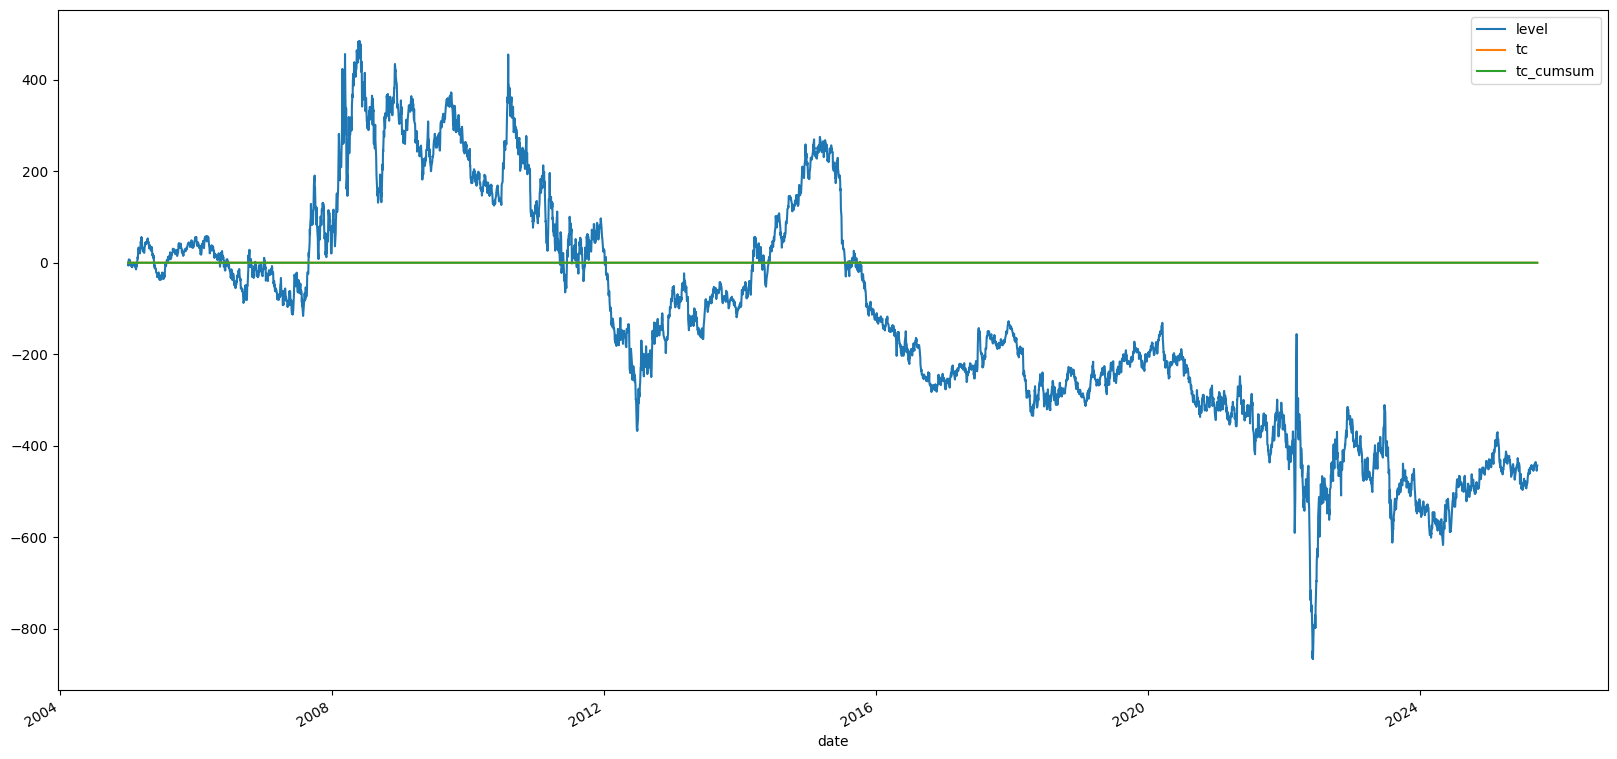

In [30]:
import numpy as np
for i,roll_schedule in enumerate(roll_schedules):
    config = {
        'start_date': start_date,
        'end_date': end_date,
        'roll_start': -5,
        'roll_schedule':roll_schedule,
        'roll_dates': 1,
        'max_position': 1,
        'longshort': 1,
        'roll_style': 'monthly',  
        'cost_type':'percentage',
        'slippage': 0,
        'commission': 0,
        'roll_out' : 1,
        'vol_target': 300000,
        'round': 0,
        'max_daily_volume': 35,
        'lookback':15,
        'vol_series':f'C:/Users/yuhang.hou/projects/holidays/poc_backtester/data/series/{cmd}/{cmd}_0_3.csv',
        'symbol':cmd

    }

    backtest = TrendBacktester(
        data = contract_df,
        config = config,
        trading_days=business_days,
        last_trading_day=ltds
    )
        
    results = backtest.run_backtest()
    res = process_results(results)
    res.plot(figsize=(20,10))

